In [1]:
import os 
import numpy as np 
import cv2 as cv
import matplotlib.pyplot as plt
from keras.preprocessing.image import load_img, img_to_array
from keras import Sequential, layers
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.xception import preprocess_input as xcep_prep
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, Xception
from tensorflow.keras.applications.efficientnet import preprocess_input


/usr/local/lib/python3.12/site-packages/jax/_src/cloud_tpu_init.py:93: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(
/usr/local/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
data_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray'

(224, 224)


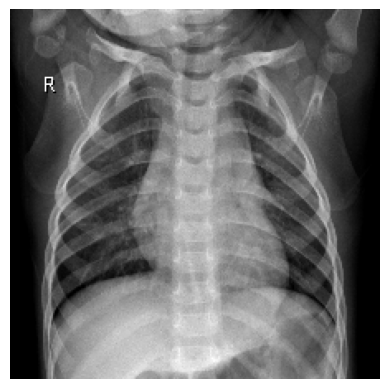

In [3]:
img_size = (224,224)
img_path = '/kaggle/input/chest-xray-pneumonia/chest_xray/train/NORMAL/IM-0117-0001.jpeg'
img = load_img(img_path, target_size = img_size, color_mode = 'rgb')

plt.imshow(img)
plt.axis('off')

print(img.size)

In [4]:
img_size = (299,299)
x = []
y = []
files = ['train','val','test']
clss = ['NORMAL','PNEUMONIA']

for file in files:
    folder = os.path.join(data_dir, file)
    for cls_ind, class_ in enumerate(clss):
        class_dir = os.path.join(folder, class_)
        for paths in os.listdir(class_dir):
            img_path = os.path.join(class_dir, paths)
            img = load_img(img_path, target_size = img_size, color_mode = 'rgb')
            img_arr = img_to_array(img)
            x.append(img_arr)
            y.append(cls_ind)
        
x = np.array(x)
y = np.array(y)

In [5]:
print(x[0])
print(y[0])

[[[41. 41. 41.]
  [ 0.  0.  0.]
  [ 0.  0.  0.]
  ...
  [ 0.  0.  0.]
  [ 0.  0.  0.]
  [ 0.  0.  0.]]

 [[ 0.  0.  0.]
  [ 0.  0.  0.]
  [ 2.  2.  2.]
  ...
  [ 1.  1.  1.]
  [ 0.  0.  0.]
  [ 0.  0.  0.]]

 [[ 0.  0.  0.]
  [ 0.  0.  0.]
  [ 0.  0.  0.]
  ...
  [ 5.  5.  5.]
  [ 1.  1.  1.]
  [ 0.  0.  0.]]

 ...

 [[35. 35. 35.]
  [35. 35. 35.]
  [31. 31. 31.]
  ...
  [37. 37. 37.]
  [36. 36. 36.]
  [38. 38. 38.]]

 [[32. 32. 32.]
  [36. 36. 36.]
  [39. 39. 39.]
  ...
  [37. 37. 37.]
  [31. 31. 31.]
  [37. 37. 37.]]

 [[ 0.  0.  0.]
  [27. 27. 27.]
  [34. 34. 34.]
  ...
  [37. 37. 37.]
  [39. 39. 39.]
  [ 8.  8.  8.]]]
0


In [6]:
xtrain, xtemp, ytrain, ytemp = train_test_split(x, y, test_size = 0.3, random_state = 3, stratify = y)
xval, xtest, yval, ytest = train_test_split(xtemp, ytemp, test_size = 0.5, random_state = 3, stratify = ytemp)

In [7]:
print(f'x train shape : {xtrain.shape}, y train shape : {ytrain.shape}')
print(f'x val shape : {xval.shape}, y val shape : {yval.shape}')
print(f'x test shape : {xtest.shape}, y test shape : {ytest.shape}')

x train shape : (4099, 299, 299, 3), y train shape : (4099,)
x val shape : (878, 299, 299, 3), y val shape : (878,)
x test shape : (879, 299, 299, 3), y test shape : (879,)


In [8]:
xtrain = xcep_prep(np.array(xtrain, dtype='float32'))
xval   = xcep_prep(np.array(xval, dtype='float32'))
xtest  = xcep_prep(np.array(xtest, dtype='float32'))

ytrain = np.array(ytrain)
yval   = np.array(yval)
ytest  = np.array(ytest)

In [9]:
xcep = Xception(
    weights = 'imagenet',
    include_top = False,
    input_shape = (299,299,3)
)
xcep.trainable = False

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
xcep_model = Sequential([
    xcep,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(32, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation = 'sigmoid')
])

xcep_model.compile(
    optimizer = 'adamax',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [11]:
xcep_model.fit(xtrain, ytrain, validation_data = (xval, yval), epochs = 20, batch_size = 16)

Epoch 1/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 120s 456ms/step - accuracy: 0.8458 - loss: 0.3474 - val_accuracy: 0.9328 - val_loss: 0.1969
Epoch 2/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 115s 446ms/step - accuracy: 0.9117 - loss: 0.2382 - val_accuracy: 0.9317 - val_loss: 0.1744
Epoch 3/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 117s 456ms/step - accuracy: 0.9232 - loss: 0.2012 - val_accuracy: 0.9396 - val_loss: 0.1573
Epoch 4/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 114s 443ms/step - accuracy: 0.9378 - loss: 0.1758 - val_accuracy: 0.9431 - val_loss: 0.1586
Epoch 5/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 114s 443ms/step - accuracy: 0.9407 - loss: 0.1671 - val_accuracy: 0.9453 - val_loss: 0.1495
Epoch 6/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 115s 448ms/step - accuracy: 0.9441 - loss: 0.1591 - val_accuracy: 0.9465 - val_loss: 0.1471
Epoch 7/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 115s 448ms/step - accuracy: 0.9507 - loss: 0.1454 - val_accuracy: 0.9419 - val_loss: 0.1520
Epoch 8/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 115s 446ms/step - accuracy: 0.9507 -

In [12]:
xcep_model.evaluate(xtest, ytest)

28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 758ms/step - accuracy: 0.9602 - loss: 0.0971


[0.09708748757839203, 0.9601820111274719]

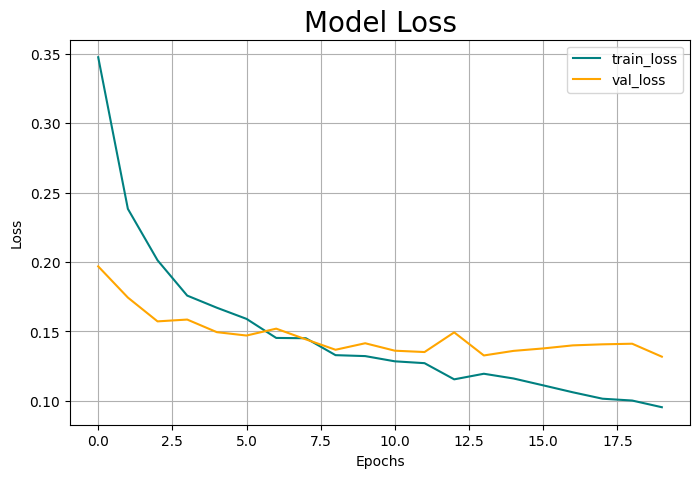

In [19]:
fig = plt.figure(figsize=(8,5)) 

plt.plot(xcep_model.history.history['loss'], color='teal', label='train_loss')
plt.plot(xcep_model.history.history['val_loss'], color='orange', label='val_loss')

plt.title('Model Loss', fontsize=20)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


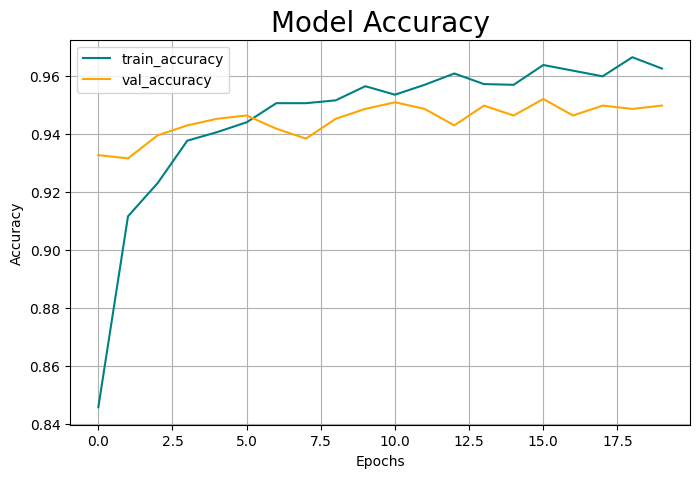

In [20]:
fig = plt.figure(figsize=(8,5))

plt.plot(xcep_model.history.history['accuracy'], color='teal', label='train_accuracy')
plt.plot(xcep_model.history.history['val_accuracy'], color='orange', label='val_accuracy')

plt.title('Model Accuracy', fontsize=20)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc="upper left")
plt.grid(True)
plt.show()


In [18]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = (xcep_model.predict(xtest) > 0.5).astype(int)
print(confusion_matrix(ytest, y_pred))
print(classification_report(ytest, y_pred, target_names=['NORMAL','PNEUMONIA']))

28/28 ━━━━━━━━━━━━━━━━━━━━ 23s 806ms/step
[[219  19]
 [ 16 625]]
              precision    recall  f1-score   support

      NORMAL       0.93      0.92      0.93       238
   PNEUMONIA       0.97      0.98      0.97       641

    accuracy                           0.96       879
   macro avg       0.95      0.95      0.95       879
weighted avg       0.96      0.96      0.96       879

